<a href="https://colab.research.google.com/github/jenny005/Reinforcement-Learning-by-Sutton-Barto/blob/main/Chapter_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example 13.1

## 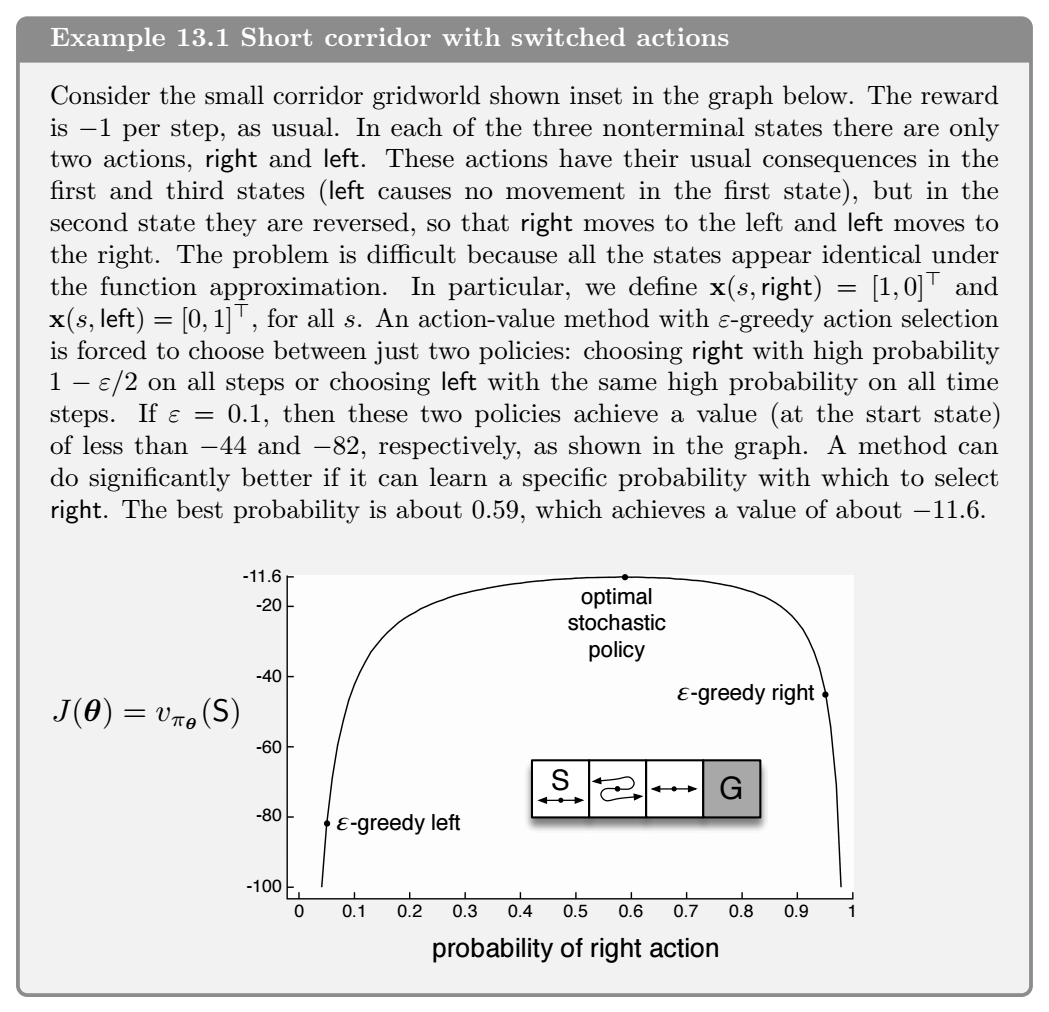

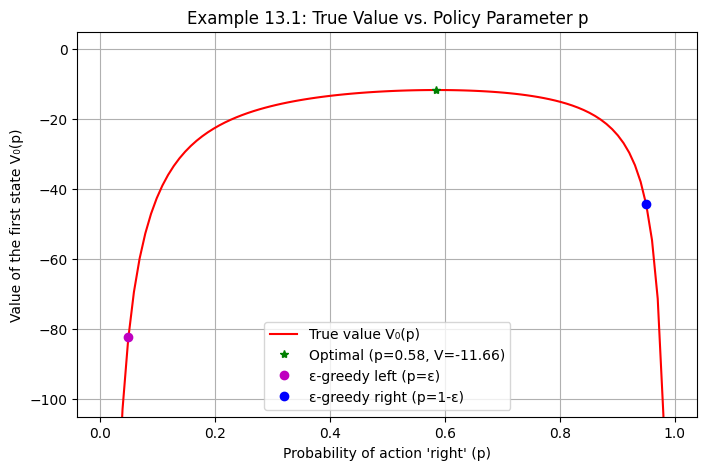

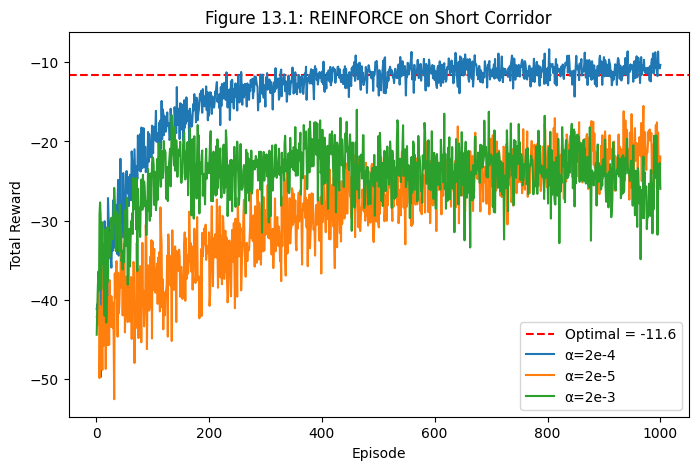

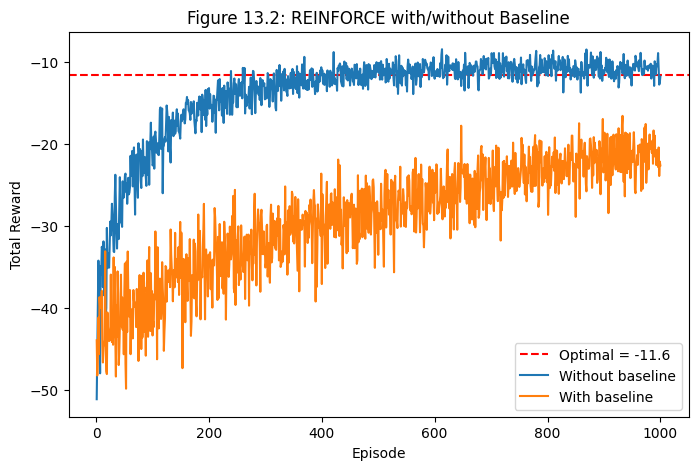

In [ ]:
# In Colab, run this cell first to enable inline plotting:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Analytic “true” value for Example 13.1 (Short Corridor)
# ----------------------------------------------------------------------
def true_value(p):
    """True value V₀(p) of the first state as a function of p = P(go right)."""
    return (2 * p - 4) / (p * (1 - p))

def plot_true_value():
    p = np.linspace(0.01, 0.99, 100)
    y = true_value(p)
    ε = 0.05

    plt.figure(figsize=(8,5))
    plt.plot(p, y, 'r-', label='True value V₀(p)')
    imax = np.argmax(y)
    plt.plot(p[imax], y[imax], 'g*',
             label=f'Optimal (p={p[imax]:.2f}, V={y[imax]:.2f})')
    plt.plot(ε, true_value(ε), 'mo', label='ε‑greedy left (p=ε)')
    plt.plot(1-ε, true_value(1-ε), 'bo', label="ε‑greedy right (p=1-ε)")

    plt.xlabel("Probability of action 'right' (p)")
    plt.ylabel("Value of the first state V₀(p)")
    plt.title("Example 13.1: True Value vs. Policy Parameter p")
    plt.ylim(-105, 5)
    plt.legend()
    plt.grid(True)
    plt.show()


# ----------------------------------------------------------------------
# 2. ShortCorridor environment (Example 13.1)
# ----------------------------------------------------------------------
class ShortCorridor:
    """
    A 4‑state “short corridor”:
    states 0,1,2 are nonterminal; state 3 is terminal.
    Action: go_right=True or False.
    Reward: –1 each step until reaching state 3.
    """
    def __init__(self):
        self.reset()

    def reset(self):
        self.state = 0
        return self.state

    def step(self, go_right):
        s = self.state
        if s in (0,2):
            self.state = s + 1 if go_right else max(0, s - 1)
        else:  # s == 1
            self.state = s - 1 if go_right else s + 1
        if self.state == 3:
            return 0, True
        else:
            return -1, False


# ----------------------------------------------------------------------
# 3. REINFORCE agents
# ----------------------------------------------------------------------
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

class ReinforceAgent:
    """
    REINFORCE Monte‐Carlo policy‐gradient (episodic) without baseline.
    θ has two entries: preference for left (0) and right (1).
    """
    def __init__(self, alpha=2e-4, gamma=1.0, ε=0.05):
        # initialize θ so initial π ≈ ε‑greedy left
        self.theta = np.array([-1.47, +1.47], dtype=float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = ε
        # feature vectors: x(s):
        # for state 0 only, but we embed action in gradient
        self.actions = []
        self.rewards = []

    def policy(self):
        prefs = self.theta
        π = softmax(prefs)
        # ensure minimal randomness
        π = np.clip(π, self.epsilon, 1-self.epsilon)
        π = π / π.sum()
        return π

    def choose(self, reward):
        if reward is not None:
            self.rewards.append(reward)
        π = self.policy()
        a = np.random.choice([0,1], p=π)  # 0=left,1=right
        self.actions.append(a)
        return bool(a)

    def learn(self, last_reward):
        self.rewards.append(last_reward)
        # compute returns G_t
        T = len(self.rewards)
        G = np.zeros(T)
        G[-1] = self.rewards[-1]
        for t in reversed(range(T-1)):
            G[t] = self.rewards[t] + self.gamma * G[t+1]
        # update θ
        for t in range(T):
            a = self.actions[t]
            π = self.policy()
            grad_log = -π
            grad_log[a] += 1
            self.theta += self.alpha * (self.gamma**t) * G[t] * grad_log
        self.actions.clear()
        self.rewards.clear()

class ReinforceBaselineAgent(ReinforceAgent):
    """
    REINFORCE with a learned baseline w.
    """
    def __init__(self, alpha=2e-5, gamma=1.0, ε=0.05, alpha_w=2e-3):
        super().__init__(alpha=alpha, gamma=gamma, ε=ε)
        self.w = 0.0
        self.alpha_w = alpha_w

    def learn(self, last_reward):
        self.rewards.append(last_reward)
        T = len(self.rewards)
        G = np.zeros(T)
        G[-1] = self.rewards[-1]
        for t in reversed(range(T-1)):
            G[t] = self.rewards[t] + self.gamma * G[t+1]
        gamma_pow = 1.0
        for t in range(T):
            # update baseline
            self.w += self.alpha_w * gamma_pow * (G[t] - self.w)
            # policy update
            a = self.actions[t]
            π = self.policy()
            grad_log = -π
            grad_log[a] += 1
            self.theta += self.alpha * gamma_pow * (G[t] - self.w) * grad_log
            gamma_pow *= self.gamma
        self.actions.clear()
        self.rewards.clear()


# ----------------------------------------------------------------------
# 4. Trial runner & Figures 13.1 & 13.2
# ----------------------------------------------------------------------
def trial(num_episodes, AgentClass):
    env = ShortCorridor()
    agent = AgentClass()
    rewards = np.zeros(num_episodes)
    for ep in range(num_episodes):
        total = 0
        reward = None
        env.reset()
        while True:
            go_right = agent.choose(reward)
            reward, done = env.step(go_right)
            total += reward
            if done:
                agent.learn(reward)
                break
        rewards[ep] = total
    return rewards

def figure_13_1(num_trials=100, num_episodes=1000):
    agents = [
        lambda: ReinforceAgent(alpha=2e-4, gamma=1.0, ε=0.05),
        lambda: ReinforceAgent(alpha=2e-5, gamma=1.0, ε=0.05),
        lambda: ReinforceAgent(alpha=2e-3, gamma=1.0, ε=0.05)
    ]
    labels = ['α=2e-4', 'α=2e-5', 'α=2e-3']
    data = np.zeros((len(agents), num_trials, num_episodes))

    for i, gen in enumerate(agents):
        for run in range(num_trials):
            data[i,run,:] = trial(num_episodes, gen)

    plt.figure(figsize=(8,5))
    plt.axhline(-11.6, color='r', linestyle='--', label='Optimal = -11.6')
    for i, label in enumerate(labels):
        plt.plot(np.arange(1,num_episodes+1), data[i].mean(axis=0), label=label)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Figure 13.1: REINFORCE on Short Corridor')
    plt.legend(loc='lower right')
    plt.show()

def figure_13_2(num_trials=100, num_episodes=1000):
    gens = [
        lambda: ReinforceAgent(alpha=2e-4, gamma=1.0, ε=0.05),
        lambda: ReinforceBaselineAgent(alpha=2e-5, gamma=1.0, ε=0.05, alpha_w=2e-3)
    ]
    labels = ['Without baseline', 'With baseline']
    data = np.zeros((len(gens), num_trials, num_episodes))

    for i, gen in enumerate(gens):
        for run in range(num_trials):
            data[i,run,:] = trial(num_episodes, gen)

    plt.figure(figsize=(8,5))
    plt.axhline(-11.6, color='r', linestyle='--', label='Optimal = -11.6')
    for i, label in enumerate(labels):
        plt.plot(np.arange(1,num_episodes+1), data[i].mean(axis=0), label=label)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Figure 13.2: REINFORCE with/without Baseline')
    plt.legend(loc='lower right')
    plt.show()


# ----------------------------------------------------------------------
# 5. Run all parts
# ----------------------------------------------------------------------
if __name__ == '__main__':
    plot_true_value()
    figure_13_1()
    figure_13_2()


/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


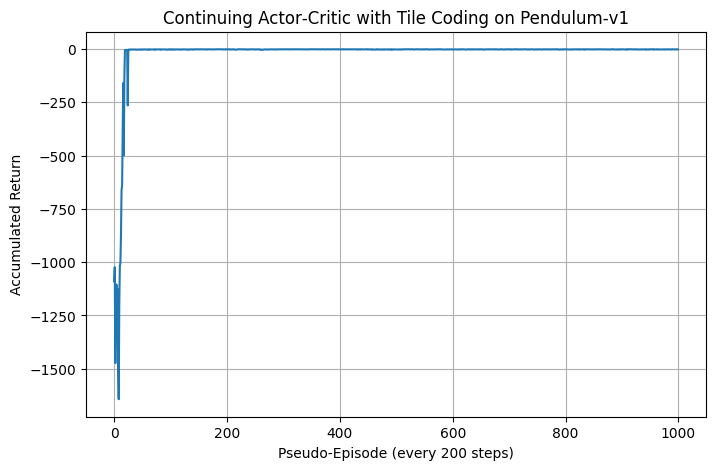

In [ ]:
# In Colab, first install dependencies:
# !pip install gym numpy matplotlib

# Enable inline plotting in Colab
%matplotlib inline

import numpy as np
# Monkey‑patch for Gym’s compatibility wrapper (old step API)
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import gym
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Manual Tile‐Coder for Pendulum state (θ, θ̇)
# ----------------------------------------------------------------------
class TileCoder:
    def __init__(self, low, high, num_tilings=8, tiles_per_dim=8):
        self.low  = np.array(low,  dtype=float)
        self.high = np.array(high, dtype=float)
        self.num_tilings   = num_tilings
        self.tiles_per_dim = tiles_per_dim
        # width of each tile in each dimension
        self.tile_width = (self.high - self.low) / (tiles_per_dim - 1)
        # offsets for each tiling: evenly spaced shifts
        self.offsets = [(i/num_tilings) * self.tile_width
                        for i in range(num_tilings)]
        # total number of features
        self.n_tiles = num_tilings * (tiles_per_dim ** 2)

    def get_tiles(self, obs):
        """Return active feature indices for 2‑D state obs=[θ, θ̇]."""
        obs = np.array(obs, dtype=float)
        feats = []
        for t, off in enumerate(self.offsets):
            coords = (obs - self.low + off) / self.tile_width
            coords = np.floor(coords).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)
            idx = t * (self.tiles_per_dim**2) \
                  + coords[0] * self.tiles_per_dim \
                  + coords[1]
            feats.append(idx)
        return feats

# ----------------------------------------------------------------------
# 2. Softmax policy helper
# ----------------------------------------------------------------------
def softmax(prefs):
    e = np.exp(prefs - np.max(prefs))
    return e / e.sum()

# ----------------------------------------------------------------------
# 3. Discretize Pendulum-v1 actions into three torques
# ----------------------------------------------------------------------
env = gym.make('Pendulum-v1')
max_torque = float(env.action_space.high[0])
actions = np.array([-max_torque, 0.0, +max_torque])
n_actions = len(actions)
env.close()

# ----------------------------------------------------------------------
# 4. Build tile coder for (θ, θ̇)
# ----------------------------------------------------------------------
# Pendulum observation: [cosθ, sinθ, θ̇]
# We convert to (θ, θ̇)
env = gym.make('Pendulum-v1')
obs = env.reset()
obs = obs[0] if isinstance(obs, tuple) else obs
max_speed = env.unwrapped.max_speed
env.close()

low  = np.array([-np.pi,   -max_speed])
high = np.array([ np.pi,    max_speed])
coder = TileCoder(low, high)
n_features = coder.n_tiles

# ----------------------------------------------------------------------
# 5. Continuing One‑step Actor‑Critic loop
# ----------------------------------------------------------------------
alpha_c = 0.1     # critic learning rate
alpha_a = 0.01    # actor learning rate
gamma   = 0.99
total_steps = 200_000   # total update steps
pseudo_ep_len = 200     # steps per pseudo-episode

# Initialize weights
w_c = np.zeros(n_features)               # critic (state‑value)
w_a = np.zeros((n_actions, n_features))  # actor (preferences)

episode_return = 0.0
returns = []
step_count = 0

# initialize env & state
env = gym.make('Pendulum-v1')
reset_out = env.reset()
obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out
theta, theta_dot = np.arctan2(obs[1], obs[0]), obs[2]
state = np.array([theta, theta_dot])

while step_count < total_steps:
    # 1) compute features φ(s)
    feats = coder.get_tiles(state)

    # 2) actor: softmax policy π(a|s)
    prefs = np.array([w_a[i, feats].sum() for i in range(n_actions)])
    probs = softmax(prefs)

    # 3) sample action index and apply torque
    a_idx  = np.random.choice(n_actions, p=probs)
    torque = [actions[a_idx]]

    # 4) step environment (ignore termination)
    out = env.step(torque)
    if len(out) == 4:
        obs2, r, _, _ = out
    else:
        obs2, r, _, _, _ = out

    episode_return += r
    step_count    += 1

    # 5) observe next state and features φ(s')
    theta2, theta_dot2 = np.arctan2(obs2[1], obs2[0]), obs2[2]
    state2 = np.array([theta2, theta_dot2])
    feats2 = coder.get_tiles(state2)

    # 6) critic: TD error δ = r + γV(s') - V(s)
    v  = w_c[feats].sum()
    v2 = w_c[feats2].sum()
    delta = r + gamma * v2 - v

    # 7) critic update
    w_c[feats] += alpha_c * delta

    # 8) actor update: ∇ log π(a|s) * δ
    for i in range(n_actions):
        grad_log = (1 if i == a_idx else 0) - probs[i]
        w_a[i, feats] += alpha_a * delta * grad_log

    # advance
    state = state2

    # record pseudo-episode return
    if step_count % pseudo_ep_len == 0:
        returns.append(episode_return)
        episode_return = 0.0

env.close()

# ----------------------------------------------------------------------
# 6. Plot learning curve
# ----------------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(returns)
plt.xlabel(f'Pseudo‑Episode (every {pseudo_ep_len} steps)')
plt.ylabel('Accumulated Return')
plt.title('Continuing Actor‑Critic with Tile Coding on Pendulum‑v1')
plt.grid(True)
plt.show()


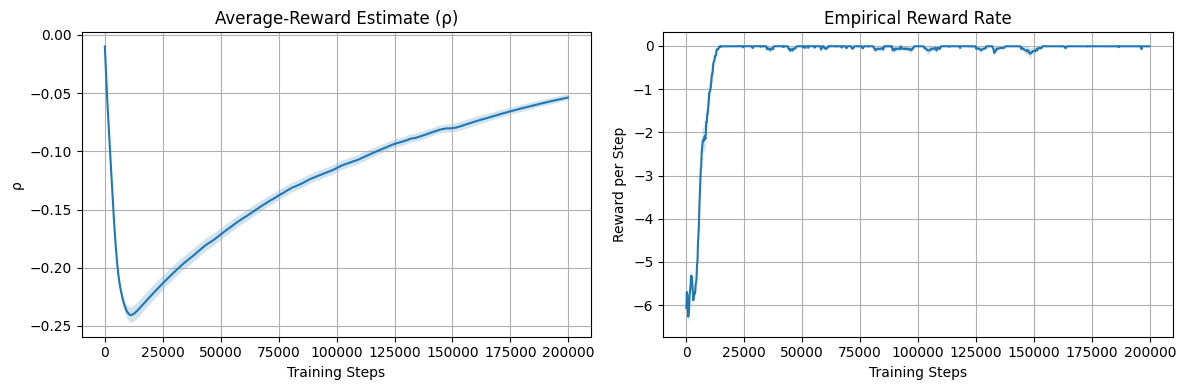

In [ ]:
# 1) Install dependencies (uncomment if needed)
# !pip install gym numpy matplotlib

# 2) Enable inline plotting
%matplotlib inline

# 3) Imports & compatibility patch
import numpy as np
import gym
import matplotlib.pyplot as plt

# For older versions of Gym
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# 4) TileCoder definition (32 tilings × 8×8)
class TileCoder:
    def __init__(self, low, high, num_tilings=32, tiles_per_dim=8):
        self.low  = np.array(low, dtype=float)
        self.high = np.array(high, dtype=float)
        self.num_tilings   = num_tilings
        self.tiles_per_dim = tiles_per_dim
        self.tile_width    = (self.high - self.low) / (tiles_per_dim - 1)
        self.offsets = [(i/num_tilings) * self.tile_width
                        for i in range(num_tilings)]
        self.n_tiles = num_tilings * (tiles_per_dim**2)

    def get_tiles(self, obs):
        obs = np.array(obs, dtype=float)
        feats = []
        for t, off in enumerate(self.offsets):
            coords = (obs - self.low + off) / self.tile_width
            coords = np.floor(coords).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)
            idx = t * (self.tiles_per_dim**2) \
                  + coords[0] * self.tiles_per_dim \
                  + coords[1]
            feats.append(idx)
        return feats

# 5) Stable softmax for action preferences
def softmax(prefs):
    prefs = np.clip(prefs, -50, 50)
    e = np.exp(prefs - np.max(prefs))
    return e / e.sum()

# 6) Environment & action discretization (new step API)
env = gym.make('Pendulum-v1', new_step_api=True)
max_torque = float(env.action_space.high[0])
actions    = np.array([-max_torque, 0.0, +max_torque])
n_actions  = len(actions)
env.close()

# 7) TileCoder instantiation for (θ, θ̇)
low  = [-np.pi, -2*np.pi]
high = [ np.pi,  2*np.pi]
coder     = TileCoder(low, high, num_tilings=32, tiles_per_dim=8)
n_features = coder.n_tiles

# 8) Hyperparameters
alpha_c       = 0.01     # critic step size
alpha_a       = 0.001    # actor step size
alpha_rho     = 1e-5     # average‑reward step size
total_steps   = 200_000
pseudo_ep_len = 200

# 9) Multi‑run experiment
num_runs   = 100
num_points = total_steps // pseudo_ep_len

all_rho    = np.zeros((num_runs, num_points))
all_reward = np.zeros((num_runs, num_points))

for run in range(num_runs):
    # Initialize weights & average‑reward estimate
    w_c = np.zeros(n_features)
    w_a = np.zeros((n_actions, n_features))
    rho = 0.0

    # Reset env and initial state
    env = gym.make('Pendulum-v1', new_step_api=True)
    obs = env.reset()
    obs = obs[0] if isinstance(obs, tuple) else obs
    state = np.array([np.arctan2(obs[1], obs[0]), obs[2]])

    step_count = 0
    ep_return  = 0.0
    rho_hist    = []
    ret_hist    = []

    while step_count < total_steps:
        feats = coder.get_tiles(state)
        prefs = np.array([w_a[i, feats].sum() for i in range(n_actions)])
        probs = softmax(prefs)
        a_idx = np.random.choice(n_actions, p=probs)

        obs2, r, *_ = env.step([actions[a_idx]])
        ep_return += r
        step_count += 1

        state2 = np.array([np.arctan2(obs2[1], obs2[0]), obs2[2]])
        feats2 = coder.get_tiles(state2)

        # Differential TD error
        v     = w_c[feats].sum()
        v2    = w_c[feats2].sum()
        delta = r - rho + (v2 - v)
        delta = np.clip(delta, -10, 10)

        # Critic update
        w_c[feats] += alpha_c * delta

        # Average‑reward update
        rho += alpha_rho * delta

        # Actor update
        for i in range(n_actions):
            grad_log = (1 if i == a_idx else 0) - probs[i]
            w_a[i, feats] += alpha_a * delta * grad_log

        # Clip weights to avoid overflow
        w_c = np.clip(w_c, -1e3, 1e3)
        w_a = np.clip(w_a, -1e3, 1e3)

        state = state2

        # Record every pseudo‑episode
        if step_count % pseudo_ep_len == 0:
            rho_hist.append(rho)
            ret_hist.append(ep_return / pseudo_ep_len)
            ep_return = 0.0

    env.close()
    all_rho[run]    = rho_hist
    all_reward[run] = ret_hist

# 10) Plotting
steps     = np.arange(num_points) * pseudo_ep_len
mean_rho  = all_rho.mean(axis=0)
se_rho    = all_rho.std(axis=0) / np.sqrt(num_runs)
mean_ret  = all_reward.mean(axis=0)
se_ret    = all_reward.std(axis=0) / np.sqrt(num_runs)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(steps, mean_rho, label='ρ estimate')
plt.fill_between(steps, mean_rho-se_rho, mean_rho+se_rho, alpha=0.2)
plt.title('Average‑Reward Estimate (ρ)')
plt.xlabel('Training Steps')
plt.ylabel('ρ')
plt.grid()

plt.subplot(1,2,2)
plt.plot(steps, mean_ret, label='Reward per Step')
plt.fill_between(steps, mean_ret-se_ret, mean_ret+se_ret, alpha=0.2)
plt.title('Empirical Reward Rate')
plt.xlabel('Training Steps')
plt.ylabel('Reward per Step')
plt.grid()

plt.tight_layout()
plt.show()
